In [1]:
import pandas as pd

df_entero = pd.read_csv('clean.csv', sep=';')

columnas_criticas = df_entero.columns[:-1]

df = df_entero.dropna(subset=columnas_criticas)

df = df.reset_index(drop=True)

print(f"Filas originales: {len(df_entero)}")
print(f"Filas tras limpieza: {len(df)}")

Filas originales: 696
Filas tras limpieza: 229


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [3]:
seed = 12

X_train, X_test, y_train, y_test = train_test_split(
                                        df.drop(columns = ["mat1BAC", "mat2BAC"]),
                                        df['mat1BAC'],
                                        random_state = seed
                                    )

In [4]:
regresion = LinearRegression()

regresion.fit(X_train, y_train)

print(f"Intercepto (b): {regresion.intercept_:.2f}")
print(regresion.coef_)

Intercepto (b): -1.73
[0.13147081 0.21668813 0.21186791 0.50856486]


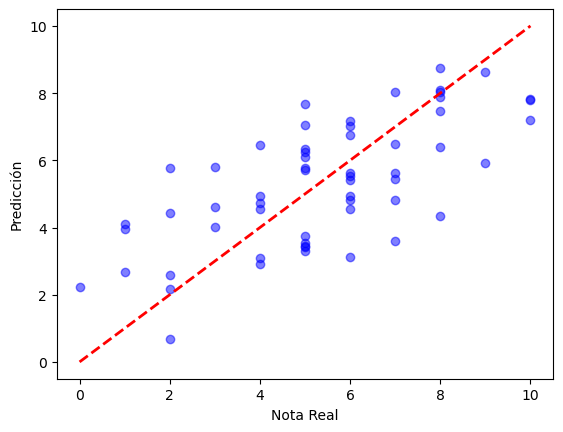

In [5]:
import matplotlib.pyplot as plt

y_pred = regresion.predict(X_test)

plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Nota Real')
plt.ylabel('Predicción')
plt.show()

In [6]:
predicciones = regresion.predict(X = X_test)

mae_dt = mean_absolute_error(
        y_true  = y_test,
        y_pred  = predicciones
       )

print(f"El error (mae) de test es: {mae_dt:.2f}")

El error (mae) de test es: 1.49
